First we will import the necessary libraries in the following block of code.

In [55]:
import numpy as np
from functools import reduce
from ripser import ripser
from collections import Counter
import matplotlib.pyplot as plt
from persim import plot_diagrams

In [56]:
cycleList = [3, 3] # <--- Change cycles to (x)

def cycleDist(i,j,n): return min((i-j)%n,(j-i)%n) # Distance between points i and j in a cycle of size n
def cycleMatrix(n): return np.array([[cycleDist(i,j,n) for i in range(n)] for j in range(n)]) # Distance matrix for the cycle graph of size n

def product(M, N): # computes the distance matrix of the product of two matrix spaces using the sum metric
	return np.block([[M + n for n in column] for column in N])

def maxProduct(M, N): # computes the distance matrix using the max matric rather than the sum metric
	return np.block([[np.maximum(M,n)  for n in column] for column in N])

def prism(M): return np.block([[M,M+1],[M+1,M]]) # Applies the prism operator we defined to a distance matrix (in other words, take the product of that metric space with the interval matric space using the sum metric

usePrism = False # <------------ CHANGE FOR PRISM OPERATION	
PrismCount = 0 # <------------ # of prism operations 

useMax = False # <------------ CHANGE FOR MAX/SUM  

It is currently unclear to me if the prism system here works but will revisit. 

In [57]:
if useMax:
    M = reduce(maxProduct, [cycleMatrix(n) for n in cycleList])
else:
    M = reduce(product, [cycleMatrix(n) for n in cycleList])
if usePrism:
    for i in range(PrismCount):
        M = prism(M)

print("Distance matrix for the product graph:")
M

Distance matrix for the product graph:


array([[0, 1, 1, 1, 2, 2, 1, 2, 2],
       [1, 0, 1, 2, 1, 2, 2, 1, 2],
       [1, 1, 0, 2, 2, 1, 2, 2, 1],
       [1, 2, 2, 0, 1, 1, 1, 2, 2],
       [2, 1, 2, 1, 0, 1, 2, 1, 2],
       [2, 2, 1, 1, 1, 0, 2, 2, 1],
       [1, 2, 2, 1, 2, 2, 0, 1, 1],
       [2, 1, 2, 2, 1, 2, 1, 0, 1],
       [2, 2, 1, 2, 2, 1, 1, 1, 0]])

List of following code blocks:

1. Barcodes & their multiplicity
2. Scatter Plot
3. Barcodes (work in progress)

In [58]:
result = ripser(M, distance_matrix=True)
diagrams = result['dgms']

print("Persistence diagrams (with multiplicity):")
for i, diagram in enumerate(diagrams):
    print(f"H{i} diagram:")
    
    # Convert rows to tuples so they can be counted
    pairs = [tuple(point) for point in diagram]
    counts = Counter(pairs)
    
    # Print each unique pair and its count
    for pair, multiplicity in counts.items():
        print(f"  Birth/Death: {pair} -> Multiplicity: {multiplicity}")


Persistence diagrams (with multiplicity):
H0 diagram:
  Birth/Death: (np.float64(0.0), np.float64(1.0)) -> Multiplicity: 8
  Birth/Death: (np.float64(0.0), np.float64(inf)) -> Multiplicity: 1
H1 diagram:
  Birth/Death: (np.float64(1.0), np.float64(2.0)) -> Multiplicity: 4


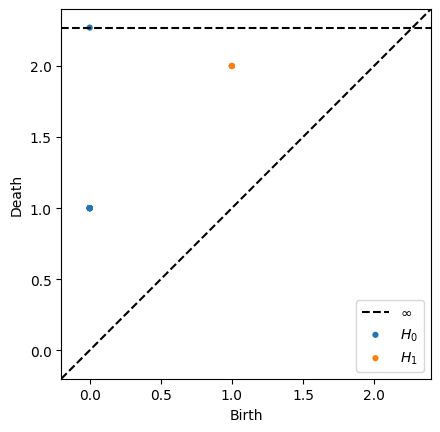

In [59]:
plot_diagrams(diagrams, show=True) # SCATTER PLOT